## 09 - Tobit espacial: captura vs anomalia de SST

Panel (celda_0.25deg x semana_ISO x temporada).  
- **Observado**: celdas con calas registradas esa semana  
- **Censurado izq.**: celdas del dominio historico sin calas esa semana  
- **Fuera del panel**: celdas que nunca fueron pescadas  
- **Variable ambiental**: anomalia SST semanal (promedio diario MODIS coarsenado a 0.25 deg)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize, approx_fprime
from scipy.stats import norm as sp_norm
from tqdm import tqdm

FEAT  = Path('/home/jupyter-daniela/suyana/peru_production/features/')
OUT   = Path('/home/jupyter-daniela/suyana/peru_production/outputs/')
PLOTS = Path('/home/jupyter-daniela/peru_catch_modeling/outputs/')

# grilla 0.25 deg (igual a SST_weekly)
REF_DS  = xr.open_dataset(FEAT / 'SST_weekly_2015-2024_4N_74W_16S_83W_0.25deg.nc')
LATS    = REF_DS.latitude.values   # shape (48,)
LONS    = REF_DS.longitude.values  # shape (34,)
REF_DS.close()

RES     = 0.25
L_CENS  = 0.0  # log(1 tm) - punto de censura izquierda

print(f'Grid: {len(LATS)} lat x {len(LONS)} lon = {len(LATS)*len(LONS)} celdas')
print(f'Lat: {LATS[0]:.3f} a {LATS[-1]:.3f}  |  Lon: {LONS[0]:.3f} a {LONS[-1]:.3f}')

Grid: 48 lat x 34 lon = 1632 celdas
Lat: -15.875 a -4.125  |  Lon: -82.875 a -74.625


In [2]:

# --- 1. Dominio historico: celdas donde alguna vez se registro una cala ---

df_raw = pd.read_csv(OUT / 'calas_all_data.csv', low_memory=False)
df_raw['fecha_cala'] = pd.to_datetime(df_raw['fecha_cala'], errors='coerce')

def get_season_type(s):
    s = str(s)
    if s.startswith('1ra') or s.endswith('CN-I'):  return '1ra'
    if s.startswith('2da') or s.endswith('CN-II'): return '2da'
    return np.nan

df_raw['season_type'] = df_raw['temporada'].apply(get_season_type)
df_raw = df_raw.dropna(subset=['latitud', 'longitud', 'fecha_cala', 'season_type'])

def snap_to_grid(vals, centers):
    idx = np.argmin(np.abs(centers[:, None] - vals[None, :]), axis=0)
    return centers[idx]

df_raw['lat_g'] = snap_to_grid(df_raw['latitud'].values,  LATS)
df_raw['lon_g'] = snap_to_grid(df_raw['longitud'].values, LONS)

# conteo historico de calas por celda
cell_counts = df_raw.groupby(['lat_g', 'lon_g']).size().rename('n_calas_hist')
print(cell_counts.describe())
print(f'\nCeldas con >= 1 cala: {(cell_counts >= 1).sum()}')
print(f'Celdas con >= 5:  {(cell_counts >= 5).sum()}')
print(f'Celdas con >= 20: {(cell_counts >= 20).sum()}')
print(f'Celdas con >= 50: {(cell_counts >= 50).sum()}')

# dominio base (umbral=1, se puede cambiar abajo)
MIN_CALAS = 1
domain_cells = set(cell_counts[cell_counts >= MIN_CALAS].index.tolist())
print(f'\nDominio con umbral {MIN_CALAS}: {len(domain_cells)} celdas')


count     324.000000
mean      985.135802
std      1313.607544
min         1.000000
25%        16.750000
50%       288.500000
75%      1602.000000
max      5398.000000
Name: n_calas_hist, dtype: float64

Celdas con >= 1 cala: 324
Celdas con >= 5:  273
Celdas con >= 20: 238
Celdas con >= 50: 215

Dominio con umbral 1: 324 celdas


In [3]:
# --- 2. Panel espacial: (temporada, semana_ISO, celda) -> catch observado o censurado ---

# ventanas temporales por temporada
season_windows = (
    df_raw.groupby('temporada')['fecha_cala']
    .agg(['min', 'max'])
    .reset_index()
)
season_windows.columns = ['temporada', 'date_min', 'date_max']

# captura semanal por celda
df_raw['iso_week'] = df_raw['fecha_cala'].dt.to_period('W').dt.start_time

catch_by_cell_week = (
    df_raw.groupby(['temporada', 'iso_week', 'lat_g', 'lon_g'])['declarado_tm']
    .sum()
    .reset_index()
    .rename(columns={'declarado_tm': 'catch_tm'})
)

# armar panel completo: todas las semanas x todas las celdas del dominio
rows = []
domain_list = list(domain_cells)

for _, sw in tqdm(season_windows.iterrows(), total=len(season_windows), desc='Temporadas'):
    temporada = sw['temporada']
    weeks = pd.date_range(sw['date_min'], sw['date_max'], freq='W-MON')
    for week in weeks:
        for (lat_g, lon_g) in domain_list:
            rows.append({'temporada': temporada, 'iso_week': week,
                         'lat_g': lat_g, 'lon_g': lon_g})

panel = pd.DataFrame(rows)

# merge con capturas observadas
panel = panel.merge(catch_by_cell_week,
                    on=['temporada', 'iso_week', 'lat_g', 'lon_g'],
                    how='left')

panel['censored']      = panel['catch_tm'].isna() | (panel['catch_tm'] <= 0)
panel['log_catch']     = np.where(panel['censored'], np.nan,
                                  np.log(panel['catch_tm'].clip(lower=1e-6)))

n_obs  = (~panel['censored']).sum()
n_cens = panel['censored'].sum()
print(f'Panel: {len(panel):,} filas | observadas: {n_obs:,} | censuradas: {n_cens:,}')
print(f'Tasa de censura: {n_cens/len(panel)*100:.1f}%')

Temporadas:   0%|          | 0/20 [00:00<?, ?it/s]

Temporadas: 100%|██████████| 20/20 [00:00<00:00, 372.09it/s]

Panel: 69,336 filas | observadas: 9,259 | censuradas: 60,077
Tasa de censura: 86.6%


In [4]:

# --- 3. SST anomalia semanal por celda 0.25 deg ---
# interpola a la grilla de referencia exacta y promedia por semana ISO

sst_weekly_list = []

for year in tqdm(range(2015, 2026), desc='SST anomaly years'):
    fpath = FEAT / f'sst_anomaly_daily_{year}.nc'
    if not fpath.exists():
        continue
    ds = xr.open_dataset(fpath)

    # interpola a la grilla de referencia (bilineal)
    ds_interp = ds.interp(lat=LATS, lon=LONS, method='linear')

    # promedio semanal (ISO week, inicio lunes)
    ds_w = ds_interp.resample(time='W-MON').mean()
    sst_weekly_list.append(ds_w)
    ds.close()

sst_weekly = xr.concat(sst_weekly_list, dim='time')
print('SST semanal lista:', sst_weekly.sizes)


SST anomaly years:   0%|          | 0/11 [00:00<?, ?it/s]

SST anomaly years:   9%|▉         | 1/11 [00:00<00:03,  2.61it/s]

SST anomaly years:  18%|█▊        | 2/11 [00:00<00:03,  2.63it/s]

SST anomaly years:  27%|██▋       | 3/11 [00:01<00:02,  2.71it/s]

SST anomaly years:  36%|███▋      | 4/11 [00:01<00:02,  2.45it/s]

...

SST anomaly years:  82%|████████▏ | 9/11 [00:03<00:00,  2.38it/s]

SST anomaly years:  91%|█████████ | 10/11 [00:04<00:00,  2.54it/s]

SST anomaly years: 100%|██████████| 11/11 [00:04<00:00,  2.65it/s]

SST anomaly years: 100%|██████████| 11/11 [00:04<00:00,  2.51it/s]

SST semanal lista: Frozen({'time': 583, 'lat': 48, 'lon': 34})


In [5]:
# --- 4. Merge panel con SST anomalia ---

# convertir xarray a dataframe largo
df_sst = (
    sst_weekly['sst_anomaly']
    .to_dataframe()
    .reset_index()
    .rename(columns={'time': 'iso_week', 'lat': 'lat_g', 'lon': 'lon_g',
                     'sst_anomaly': 'sst_anom'})
    .dropna(subset=['sst_anom'])
)
df_sst['iso_week'] = pd.to_datetime(df_sst['iso_week'])

panel['iso_week'] = pd.to_datetime(panel['iso_week'])
panel = panel.merge(df_sst, on=['iso_week', 'lat_g', 'lon_g'], how='left')
panel = panel.dropna(subset=['sst_anom'])

n_obs2  = (~panel['censored']).sum()
n_cens2 = panel['censored'].sum()
print(f'Panel tras merge SST: {len(panel):,} filas | obs: {n_obs2:,} | cens: {n_cens2:,}')
print(f'Tasa de censura: {n_cens2/len(panel)*100:.1f}%')

Panel tras merge SST: 51,627 filas | obs: 7,797 | cens: 43,830
Tasa de censura: 84.9%


In [6]:
# --- 5. Tobit espacial ---

def tobit_nll(params, X, y, censored, L=L_CENS):
    beta  = params[:-1]
    sigma = np.exp(params[-1])
    xb    = X @ beta
    ll    = np.zeros(len(y))
    ll[~censored] = sp_norm.logpdf(y[~censored], loc=xb[~censored], scale=sigma)
    ll[ censored] = sp_norm.logcdf(L,            loc=xb[censored],  scale=sigma)
    return -ll.sum()

def fit_tobit(x_vals, y_vals, cens_mask, L=L_CENS):
    X = np.column_stack([np.ones(len(x_vals)), x_vals])
    y = y_vals.copy()
    y[cens_mask] = L
    obs = ~cens_mask
    if obs.sum() < 5:
        return None
    b0   = np.linalg.lstsq(X[obs], y[obs], rcond=None)[0]
    resid = y[obs] - X[obs] @ b0
    p0   = np.append(b0, np.log(resid.std() + 1e-6))
    res  = minimize(tobit_nll, p0, args=(X, y, cens_mask, L),
                    method='L-BFGS-B', options={'maxiter': 5000, 'ftol': 1e-10})
    if not res.success:
        return None
    # error estandar via hessiana numerica
    eps   = 1e-5; n = len(res.x)
    grad0 = approx_fprime(res.x, lambda p: tobit_nll(p, X, y, cens_mask, L), eps)
    hess  = np.zeros((n, n))
    for i in range(n):
        xf = res.x.copy(); xf[i] += eps
        hess[i] = (approx_fprime(xf, lambda p: tobit_nll(p, X, y, cens_mask, L), eps) - grad0) / eps
    hess = (hess + hess.T) / 2
    vcov = np.linalg.pinv(hess)
    se   = np.sqrt(np.maximum(np.diag(vcov)[:-1], 0))
    return {'beta': res.x[1], 'se': se[1], 'sigma': np.exp(res.x[-1]),
            'intercept': res.x[0]}

# --- pooled (todas las temporadas) ---
sub   = panel.dropna(subset=['sst_anom', 'log_catch'])
# para censuradas, log_catch puede ser nan -> usar L
x_all = panel['sst_anom'].values
y_all = panel['log_catch'].fillna(L_CENS).values
c_all = panel['censored'].values

print('Ajustando Tobit pooled...')
r_pool = fit_tobit(x_all, y_all, c_all)
print(f"beta_SST = {r_pool['beta']:+.4f}  SE = {r_pool['se']:.4f}  "
      f"t = {r_pool['beta']/r_pool['se']:.2f}")
print(f"Semi-elasticidad: 1 deg de anomalia -> {(np.exp(r_pool['beta'])-1)*100:+.1f}% cambio en captura")

Ajustando Tobit pooled...


beta_SST = -1.5120  SE = 0.0688  t = -21.99
Semi-elasticidad: 1 deg de anomalia -> -78.0% cambio en captura


In [7]:
# --- por temporada (1ra vs 2da) ---
panel['season_type'] = panel['temporada'].apply(get_season_type)

results = {}
for stype in ['1ra', '2da']:
    sub = panel[panel['season_type'] == stype]
    x   = sub['sst_anom'].values
    y   = sub['log_catch'].fillna(L_CENS).values
    c   = sub['censored'].values
    r   = fit_tobit(x, y, c)
    results[stype] = r
    label = 'Primera' if stype == '1ra' else 'Segunda'
    print(f"{label} temporada | beta = {r['beta']:+.4f}  SE = {r['se']:.4f}  "
          f"t = {r['beta']/r['se']:.2f}  "
          f"-> {(np.exp(r['beta'])-1)*100:+.1f}% por 1 deg")

Primera temporada | beta = -1.7300  SE = 0.0972  t = -17.81  -> -82.3% por 1 deg


Segunda temporada | beta = -1.3053  SE = 0.1017  t = -12.83  -> -72.9% por 1 deg


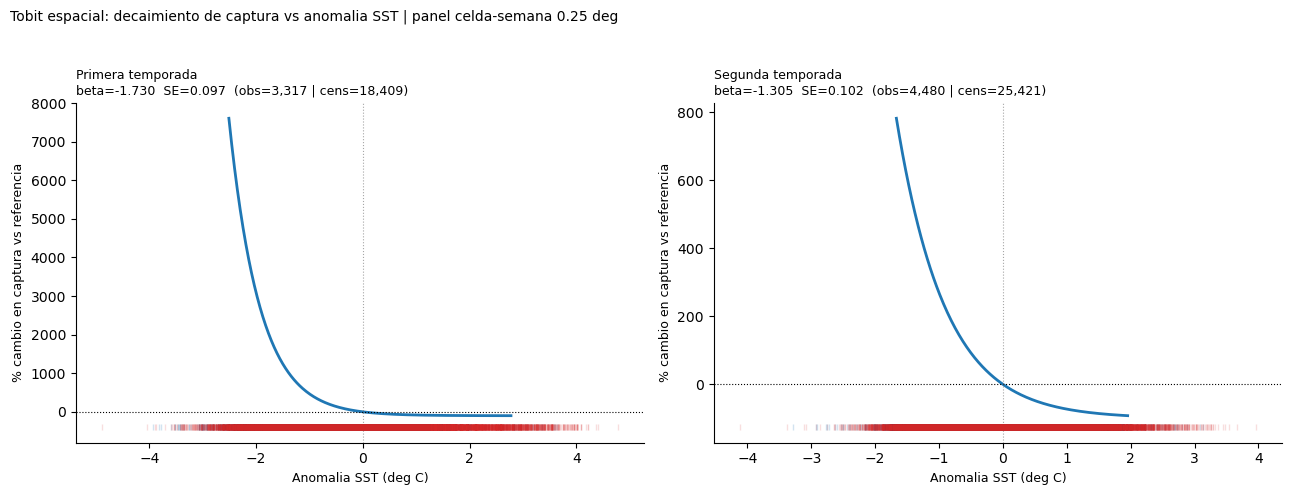

Guardado -> /home/jupyter-daniela/peru_catch_modeling/outputs/step9_spatial_tobit.png


In [8]:
# --- Grafico: curva de decaimiento Tobit espacial ---
TAB = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels_map = {'1ra': 'Primera temporada', '2da': 'Segunda temporada'}

for ax, stype in zip(axes, ['1ra', '2da']):
    r   = results[stype]
    sub = panel[panel['season_type'] == stype]

    x_range = np.linspace(sub['sst_anom'].quantile(0.02),
                          sub['sst_anom'].quantile(0.98), 300)
    ref     = 0.0
    y_tb    = (np.exp(r['beta'] * (x_range - ref)) - 1) * 100

    ax.plot(x_range, y_tb, color=TAB[0], lw=2)
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.axvline(0, color='grey', lw=0.8, ls=':', alpha=0.7)

    # rug: observados vs censurados
    obs_x  = sub.loc[~sub['censored'], 'sst_anom']
    cens_x = sub.loc[sub['censored'],  'sst_anom']
    ymin, ymax = ax.get_ylim()
    rug_y = ymin + 0.01 * (ymax - ymin)
    ax.plot(obs_x,  np.full(len(obs_x),  rug_y), '|', color=TAB[0], alpha=0.2, ms=5)
    ax.plot(cens_x, np.full(len(cens_x), rug_y), '|', color=TAB[3], alpha=0.15, ms=5)

    n_obs_s  = (~sub['censored']).sum()
    n_cens_s = sub['censored'].sum()
    ax.set_title(
        f"{labels_map[stype]}\n"
        f"beta={r['beta']:+.3f}  SE={r['se']:.3f}  "
        f"(obs={n_obs_s:,} | cens={n_cens_s:,})",
        fontsize=9, loc='left'
    )
    ax.set_xlabel('Anomalia SST (deg C)', fontsize=9)
    ax.set_ylabel('% cambio en captura vs referencia', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Tobit espacial: decaimiento de captura vs anomalia SST | panel celda-semana 0.25 deg',
             x=0.01, ha='left', fontsize=10, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(PLOTS / 'step9_spatial_tobit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado -> {PLOTS / "step9_spatial_tobit.png"}')

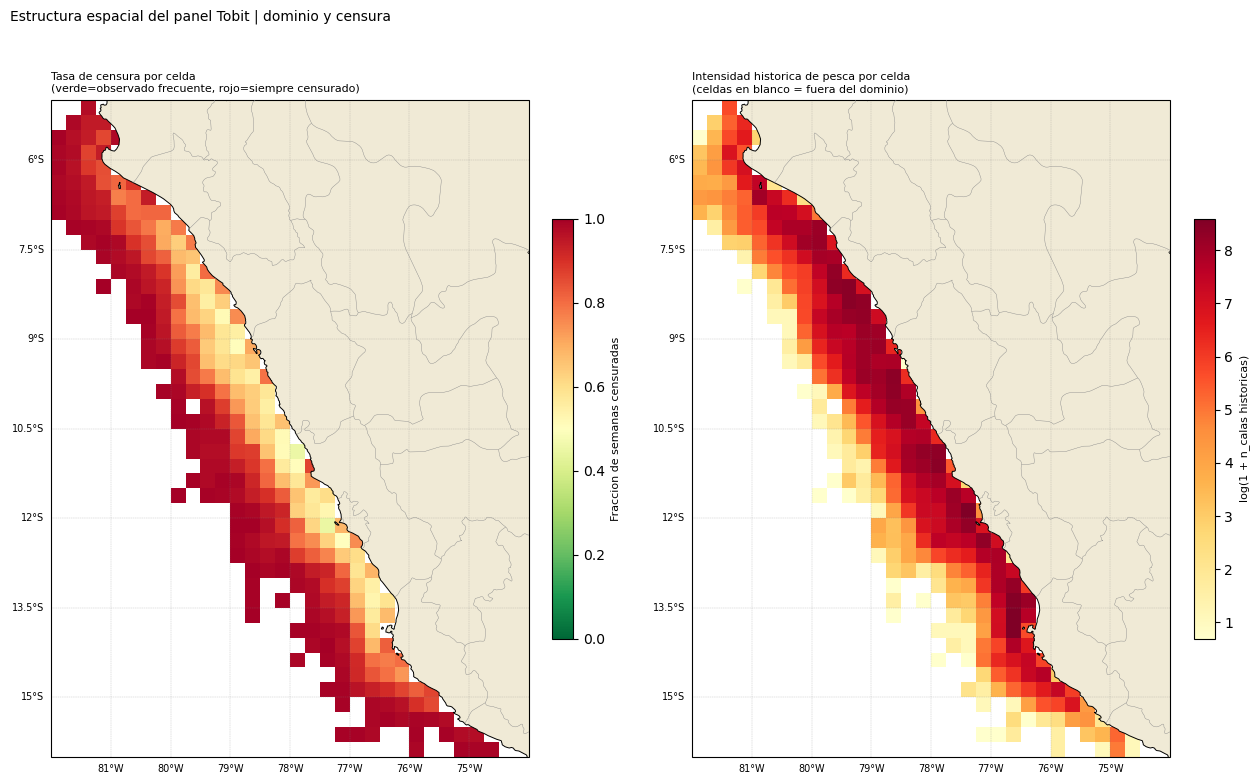

Guardado -> /home/jupyter-daniela/peru_catch_modeling/outputs/step9b_spatial_censure_map.png


In [9]:

# --- Mapa: frecuencia de censura por celda ---
import cartopy.crs as ccrs
import cartopy.feature as cfeature

PROJ = ccrs.PlateCarree()

# fraccion de semanas-temporada en que cada celda fue censurada
cens_freq = (
    panel.groupby(['lat_g', 'lon_g'])['censored']
    .mean()
    .rename('cens_rate')
    .reset_index()
)
# conteo historico para colorear el dominio
cc_df = cell_counts.reset_index()

# grilla 2D para plot
lon_grid, lat_grid = np.meshgrid(LONS, LATS)
cens_map = np.full(lon_grid.shape, np.nan)
hist_map = np.full(lon_grid.shape, np.nan)

for _, row in cens_freq.iterrows():
    i = np.argmin(np.abs(LATS - row['lat_g']))
    j = np.argmin(np.abs(LONS - row['lon_g']))
    cens_map[i, j] = row['cens_rate']

for _, row in cc_df.iterrows():
    i = np.argmin(np.abs(LATS - row['lat_g']))
    j = np.argmin(np.abs(LONS - row['lon_g']))
    hist_map[i, j] = row['n_calas_hist']

states_10m = cfeature.NaturalEarthFeature(
    'cultural', 'admin_1_states_provinces_lines', '10m', facecolor='none')

fig, axes = plt.subplots(1, 2, figsize=(13, 8), subplot_kw={'projection': PROJ})
EXT = [-82, -74, -16, -5]

# panel izquierdo: frecuencia de censura
ax = axes[0]
ax.set_extent(EXT, crs=PROJ)
ax.add_feature(cfeature.LAND,      facecolor='#f0ead6', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, zorder=3)
ax.add_feature(states_10m,         linewidth=0.3, edgecolor='#888', zorder=3)
m1 = ax.pcolormesh(LONS, LATS, cens_map,
                   transform=PROJ, cmap='RdYlGn_r', vmin=0, vmax=1, zorder=1)
cb1 = plt.colorbar(m1, ax=ax, shrink=0.6, pad=0.04)
cb1.set_label('Fraccion de semanas censuradas', size=8)
ax.set_title('Tasa de censura por celda\n(verde=observado frecuente, rojo=siempre censurado)',
             fontsize=8, loc='left')

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='grey',
                  alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 7}

# panel derecho: calas historicas por celda (log scale)
ax = axes[1]
ax.set_extent(EXT, crs=PROJ)
ax.add_feature(cfeature.LAND,      facecolor='#f0ead6', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, zorder=3)
ax.add_feature(states_10m,         linewidth=0.3, edgecolor='#888', zorder=3)
m2 = ax.pcolormesh(LONS, LATS, np.log1p(hist_map),
                   transform=PROJ, cmap='YlOrRd', zorder=1)
cb2 = plt.colorbar(m2, ax=ax, shrink=0.6, pad=0.04)
cb2.set_label('log(1 + n_calas historicas)', size=8)
ax.set_title('Intensidad historica de pesca por celda\n(celdas en blanco = fuera del dominio)',
             fontsize=8, loc='left')

gl2 = ax.gridlines(draw_labels=True, linewidth=0.3, color='grey',
                   alpha=0.5, linestyle='--')
gl2.top_labels = gl2.right_labels = False
gl2.xlabel_style = gl2.ylabel_style = {'size': 7}

fig.suptitle('Estructura espacial del panel Tobit | dominio y censura',
             x=0.01, ha='left', fontsize=10, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(PLOTS / 'step9b_spatial_censure_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado -> {PLOTS / "step9b_spatial_censure_map.png"}')


Umbrales:   0%|          | 0/6 [00:00<?, ?it/s]

Umbrales:  17%|█▋        | 1/6 [00:02<00:12,  2.42s/it]

min_calas=   1 | dominio=324 celdas | censura=84.9% | beta=-1.512 SE=0.069


Umbrales:  33%|███▎      | 2/6 [00:04<00:08,  2.22s/it]

min_calas=   5 | dominio=273 celdas | censura=82.4% | beta=-1.450 SE=0.067


...

Umbrales:  83%|████████▎ | 5/6 [00:10<00:02,  2.09s/it]

min_calas=  50 | dominio=215 celdas | censura=78.7% | beta=-1.393 SE=0.065


Umbrales: 100%|██████████| 6/6 [00:12<00:00,  2.06s/it]

Umbrales: 100%|██████████| 6/6 [00:12<00:00,  2.12s/it]

min_calas= 100 | dominio=196 celdas | censura=77.2% | beta=-1.382 SE=0.065


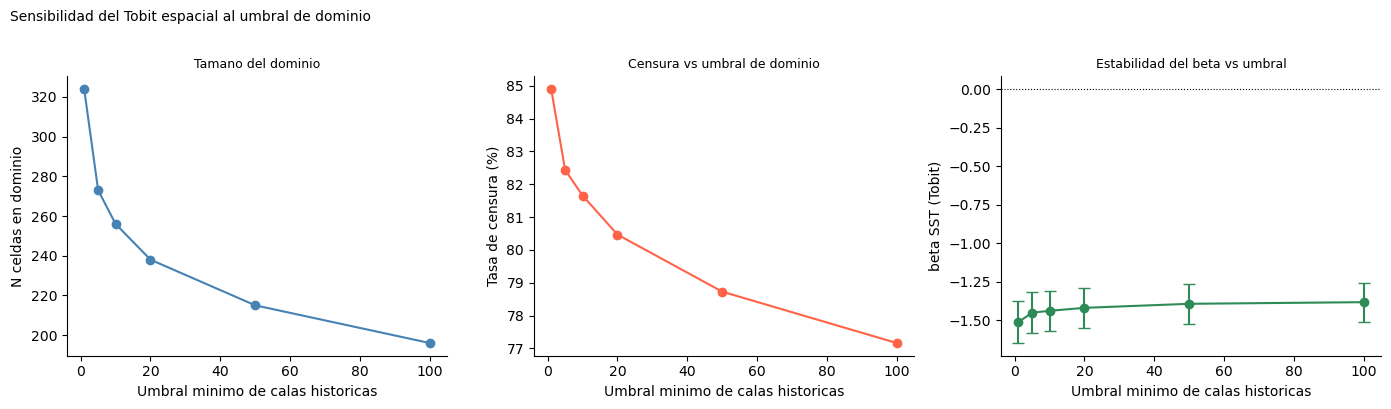

Guardado -> /home/jupyter-daniela/peru_catch_modeling/outputs/step9c_tobit_sensitivity_domain.png


In [10]:

# --- Sensibilidad del beta al umbral de dominio ---
# Variamos MIN_CALAS y refitamos el Tobit pooled para ver como cambia beta y tasa de censura

def build_panel_and_fit(min_calas, df_raw, season_windows, sst_weekly, cell_counts):
    domain = set(cell_counts[cell_counts >= min_calas].index.tolist())

    # panel
    rows = []
    for _, sw in season_windows.iterrows():
        weeks = pd.date_range(sw['date_min'], sw['date_max'], freq='W-MON')
        for week in weeks:
            for (lat_g, lon_g) in domain:
                rows.append({'temporada': sw['temporada'], 'iso_week': week,
                             'lat_g': lat_g, 'lon_g': lon_g})
    panel_s = pd.DataFrame(rows)

    df_raw2 = df_raw.copy()
    df_raw2['iso_week'] = df_raw2['fecha_cala'].dt.to_period('W').dt.start_time
    catch_s = (df_raw2.groupby(['temporada', 'iso_week', 'lat_g', 'lon_g'])['declarado_tm']
               .sum().reset_index().rename(columns={'declarado_tm': 'catch_tm'}))

    panel_s = panel_s.merge(catch_s, on=['temporada', 'iso_week', 'lat_g', 'lon_g'], how='left')
    panel_s['censored']  = panel_s['catch_tm'].isna() | (panel_s['catch_tm'] <= 0)
    panel_s['log_catch'] = np.where(panel_s['censored'], np.nan,
                                    np.log(panel_s['catch_tm'].clip(lower=1e-6)))

    # merge SST
    df_sst2 = (sst_weekly['sst_anomaly'].to_dataframe().reset_index()
               .rename(columns={'time': 'iso_week', 'lat': 'lat_g', 'lon': 'lon_g',
                                'sst_anomaly': 'sst_anom'})
               .dropna(subset=['sst_anom']))
    df_sst2['iso_week'] = pd.to_datetime(df_sst2['iso_week'])
    panel_s['iso_week'] = pd.to_datetime(panel_s['iso_week'])
    panel_s = panel_s.merge(df_sst2, on=['iso_week', 'lat_g', 'lon_g'], how='left')
    panel_s = panel_s.dropna(subset=['sst_anom'])

    cens_rate = panel_s['censored'].mean()
    n_obs_s   = (~panel_s['censored']).sum()

    x = panel_s['sst_anom'].values
    y = panel_s['log_catch'].fillna(L_CENS).values
    c = panel_s['censored'].values
    r = fit_tobit(x, y, c)

    return {'min_calas': min_calas, 'n_domain': len(domain),
            'n_panel': len(panel_s), 'n_obs': n_obs_s,
            'cens_rate': cens_rate, 'beta': r['beta'] if r else np.nan,
            'se': r['se'] if r else np.nan}

thresholds = [1, 5, 10, 20, 50, 100]
sensitivity = []
for thr in tqdm(thresholds, desc='Umbrales'):
    res = build_panel_and_fit(thr, df_raw, season_windows, sst_weekly, cell_counts)
    sensitivity.append(res)
    print(f"min_calas={thr:4d} | dominio={res['n_domain']:3d} celdas | "
          f"censura={res['cens_rate']*100:.1f}% | beta={res['beta']:+.3f} SE={res['se']:.3f}")

df_sens = pd.DataFrame(sensitivity)

# grafico
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(df_sens['min_calas'], df_sens['n_domain'], 'o-', color='steelblue')
axes[0].set_xlabel('Umbral minimo de calas historicas')
axes[0].set_ylabel('N celdas en dominio')
axes[0].set_title('Tamano del dominio', fontsize=9)

axes[1].plot(df_sens['min_calas'], df_sens['cens_rate'] * 100, 'o-', color='tomato')
axes[1].set_xlabel('Umbral minimo de calas historicas')
axes[1].set_ylabel('Tasa de censura (%)')
axes[1].set_title('Censura vs umbral de dominio', fontsize=9)

axes[2].errorbar(df_sens['min_calas'], df_sens['beta'],
                 yerr=1.96 * df_sens['se'], fmt='o-', color='seagreen', capsize=4)
axes[2].axhline(0, color='k', lw=0.8, ls=':')
axes[2].set_xlabel('Umbral minimo de calas historicas')
axes[2].set_ylabel('beta SST (Tobit)')
axes[2].set_title('Estabilidad del beta vs umbral', fontsize=9)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Sensibilidad del Tobit espacial al umbral de dominio',
             x=0.01, ha='left', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS / 'step9c_tobit_sensitivity_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado -> {PLOTS / "step9c_tobit_sensitivity_domain.png"}')


In [11]:

# --- Tobit por umbral (1500 y 2000) y por region ---

# regiones IMARPE
def assign_region(lat):
    if   lat > -8:   return 'Norte'
    elif lat > -12:  return 'Centro'
    else:            return 'Sur'

THRESHOLDS = [1500, 2000]

all_results = {}

for MIN_C in THRESHOLDS:
    domain_c = set(cell_counts[cell_counts >= MIN_C].index.tolist())
    print(f'\n{"="*60}')
    print(f'Umbral {MIN_C} calas | dominio: {len(domain_c)} celdas')
    print(f'{"="*60}')

    # panel
    rows = []
    for _, sw in season_windows.iterrows():
        weeks = pd.date_range(sw['date_min'], sw['date_max'], freq='W-MON')
        for week in weeks:
            for (lat_g, lon_g) in domain_c:
                rows.append({'temporada': sw['temporada'], 'iso_week': week,
                             'lat_g': lat_g, 'lon_g': lon_g})
    panel_c = pd.DataFrame(rows)

    df_raw2 = df_raw.copy()
    df_raw2['iso_week'] = df_raw2['fecha_cala'].dt.to_period('W').dt.start_time
    catch_c = (df_raw2.groupby(['temporada', 'iso_week', 'lat_g', 'lon_g'])['declarado_tm']
               .sum().reset_index().rename(columns={'declarado_tm': 'catch_tm'}))

    panel_c = panel_c.merge(catch_c, on=['temporada','iso_week','lat_g','lon_g'], how='left')
    panel_c['censored']  = panel_c['catch_tm'].isna() | (panel_c['catch_tm'] <= 0)
    panel_c['log_catch'] = np.where(panel_c['censored'], np.nan,
                                    np.log(panel_c['catch_tm'].clip(lower=1e-6)))

    df_sst2 = (sst_weekly['sst_anomaly'].to_dataframe().reset_index()
               .rename(columns={'time':'iso_week','lat':'lat_g','lon':'lon_g','sst_anomaly':'sst_anom'})
               .dropna(subset=['sst_anom']))
    df_sst2['iso_week'] = pd.to_datetime(df_sst2['iso_week'])
    panel_c['iso_week']  = pd.to_datetime(panel_c['iso_week'])
    panel_c = panel_c.merge(df_sst2, on=['iso_week','lat_g','lon_g'], how='left')
    panel_c = panel_c.dropna(subset=['sst_anom'])

    panel_c['region']      = panel_c['lat_g'].apply(assign_region)
    panel_c['season_type'] = panel_c['temporada'].apply(get_season_type)

    cens_rate = panel_c['censored'].mean()
    print(f'Panel: {len(panel_c):,} filas | obs: {(~panel_c["censored"]).sum():,} | '
          f'cens: {panel_c["censored"].sum():,} | tasa: {cens_rate*100:.1f}%')

    rows_res = []

    # pooled
    r = fit_tobit(panel_c['sst_anom'].values,
                  panel_c['log_catch'].fillna(L_CENS).values,
                  panel_c['censored'].values)
    rows_res.append({'grupo': 'Pooled', 'region': '-', 'season': '-',
                     'beta': r['beta'], 'se': r['se'],
                     'n_obs': (~panel_c['censored']).sum(),
                     'n_cens': panel_c['censored'].sum()})
    print(f"  Pooled           | beta={r['beta']:+.4f}  SE={r['se']:.4f}  "
          f"t={r['beta']/r['se']:.2f}  -> {(np.exp(r['beta'])-1)*100:+.1f}%")

    # por region
    for reg in ['Norte', 'Centro', 'Sur']:
        sub = panel_c[panel_c['region'] == reg]
        if len(sub) < 20: continue
        r = fit_tobit(sub['sst_anom'].values,
                      sub['log_catch'].fillna(L_CENS).values,
                      sub['censored'].values)
        if r is None: continue
        rows_res.append({'grupo': 'Region', 'region': reg, 'season': '-',
                         'beta': r['beta'], 'se': r['se'],
                         'n_obs': (~sub['censored']).sum(),
                         'n_cens': sub['censored'].sum()})
        print(f"  {reg:<16} | beta={r['beta']:+.4f}  SE={r['se']:.4f}  "
              f"t={r['beta']/r['se']:.2f}  -> {(np.exp(r['beta'])-1)*100:+.1f}%")

    # por region x temporada
    for reg in ['Norte', 'Centro', 'Sur']:
        for stype in ['1ra', '2da']:
            sub = panel_c[(panel_c['region']==reg) & (panel_c['season_type']==stype)]
            if len(sub) < 20: continue
            r = fit_tobit(sub['sst_anom'].values,
                          sub['log_catch'].fillna(L_CENS).values,
                          sub['censored'].values)
            if r is None: continue
            lbl = 'Primera' if stype=='1ra' else 'Segunda'
            rows_res.append({'grupo': 'Region x Temporada', 'region': reg, 'season': lbl,
                             'beta': r['beta'], 'se': r['se'],
                             'n_obs': (~sub['censored']).sum(),
                             'n_cens': sub['censored'].sum()})
            print(f"  {reg:<10} {lbl:<10} | beta={r['beta']:+.4f}  SE={r['se']:.4f}  "
                  f"t={r['beta']/r['se']:.2f}  -> {(np.exp(r['beta'])-1)*100:+.1f}%")

    all_results[MIN_C] = {'panel': panel_c, 'results': pd.DataFrame(rows_res)}



Umbral 1500 calas | dominio: 88 celdas


Panel: 15,559 filas | obs: 5,459 | cens: 10,100 | tasa: 64.9%


  Pooled           | beta=-1.2788  SE=0.0695  t=-18.39  -> -72.2%
  Norte            | beta=-1.3159  SE=0.1904  t=-6.91  -> -73.2%


  Centro           | beta=-1.2638  SE=0.0838  t=-15.08  -> -71.7%
  Sur              | beta=-1.2927  SE=0.1604  t=-8.06  -> -72.5%
  Norte      Primera    | beta=-0.7446  SE=0.2777  t=-2.68  -> -52.5%


  Norte      Segunda    | beta=-1.8885  SE=0.2625  t=-7.19  -> -84.9%
  Centro     Primera    | beta=-1.6603  SE=0.1214  t=-13.68  -> -81.0%
  Centro     Segunda    | beta=-0.9290  SE=0.1220  t=-7.62  -> -60.5%


...

Panel: 12,767 filas | obs: 4,815 | cens: 7,952 | tasa: 62.3%
  Pooled           | beta=-1.2743  SE=0.0718  t=-17.75  -> -72.0%


  Norte            | beta=-1.3669  SE=0.2081  t=-6.57  -> -74.5%
  Centro           | beta=-1.2415  SE=0.0851  t=-14.59  -> -71.1%


  Sur              | beta=-1.3771  SE=0.1732  t=-7.95  -> -74.8%
  Norte      Primera    | beta=-0.7142  SE=0.3167  t=-2.26  -> -51.0%
  Norte      Segunda    | beta=-1.9678  SE=0.2762  t=-7.12  -> -86.0%


  Centro     Primera    | beta=-1.6224  SE=0.1238  t=-13.10  -> -80.3%
  Centro     Segunda    | beta=-0.9334  SE=0.1232  t=-7.58  -> -60.7%
  Sur        Primera    | beta=-2.0264  SE=0.2287  t=-8.86  -> -86.8%


  Sur        Segunda    | beta=-0.3485  SE=0.2714  t=-1.28  -> -29.4%


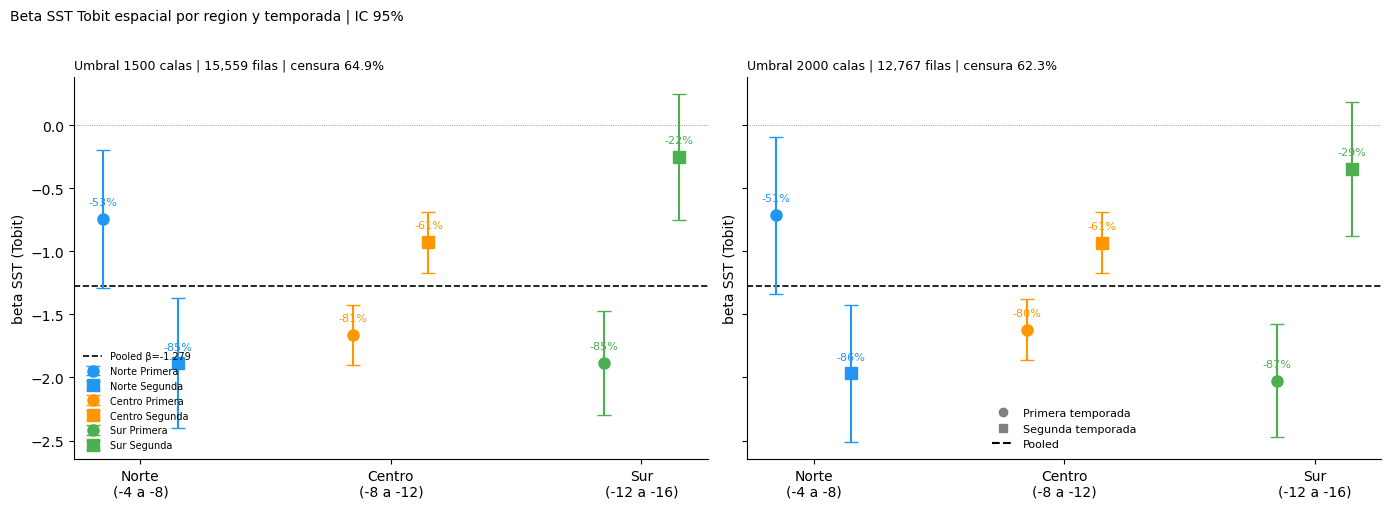

Guardado -> /home/jupyter-daniela/peru_catch_modeling/outputs/step9d_tobit_by_region.png


In [12]:

# --- Grafico: beta por region y umbral ---
REGION_COLORS = {'Norte': '#2196F3', 'Centro': '#FF9800', 'Sur': '#4CAF50'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, thr in zip(axes, THRESHOLDS):
    df_r = all_results[thr]['results']
    df_reg = df_r[df_r['grupo'] == 'Region x Temporada'].copy()
    df_pool = df_r[df_r['grupo'] == 'Pooled'].iloc[0]

    # pooled como linea de referencia
    ax.axhline(df_pool['beta'], color='k', lw=1.2, ls='--', label=f"Pooled β={df_pool['beta']:+.3f}")
    ax.axhline(0, color='grey', lw=0.6, ls=':')

    x_pos = {'Norte': 0, 'Centro': 1, 'Sur': 2}
    offset = {'Primera': -0.15, 'Segunda': 0.15}
    marker = {'Primera': 'o', 'Segunda': 's'}

    for _, row in df_reg.iterrows():
        x = x_pos[row['region']] + offset[row['season']]
        ax.errorbar(x, row['beta'], yerr=1.96*row['se'],
                    fmt=marker[row['season']],
                    color=REGION_COLORS[row['region']],
                    capsize=5, markersize=8,
                    label=f"{row['region']} {row['season']}" if thr == THRESHOLDS[0] else '')
        ax.annotate(f"{(np.exp(row['beta'])-1)*100:+.0f}%",
                    xy=(x, row['beta']), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=8,
                    color=REGION_COLORS[row['region']])

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Norte\n(-4 a -8)', 'Centro\n(-8 a -12)', 'Sur\n(-12 a -16)'])
    ax.set_ylabel('beta SST (Tobit)')
    ax.set_title(f'Umbral {thr} calas | {len(all_results[thr]["panel"]):,} filas | '
                 f'censura {all_results[thr]["panel"]["censored"].mean()*100:.1f}%',
                 fontsize=9, loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if thr == THRESHOLDS[0]:
        ax.legend(fontsize=7, frameon=False, loc='lower left')

# leyenda de markers
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='grey', ls='none', label='Primera temporada'),
           Line2D([0],[0], marker='s', color='grey', ls='none', label='Segunda temporada'),
           Line2D([0],[0], color='k', ls='--', label='Pooled')]
axes[1].legend(handles=handles, fontsize=8, frameon=False)

fig.suptitle('Beta SST Tobit espacial por region y temporada | IC 95%',
             x=0.01, ha='left', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS / 'step9d_tobit_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado -> {PLOTS / "step9d_tobit_by_region.png"}')
